In [1]:
import json
import math
import os
from collections import namedtuple
from typing import List, Tuple
from joblib import Parallel, delayed


In [2]:
import sys 
sys.path.append('../')

In [3]:
import torch
import torchaudio
import torchaudio.functional as F
from pytorch_lightning import LightningModule
from corpus.gigaspeech import GigaDataset
from src.text import load_text_encoder
from src.asr import ASR
from src.optim import Optimizer
from src.util import cal_er
from src.decode import BeamDecoder


In [4]:
from src.giga_las_lightning import CustomDataset

In [21]:
# %%timeit
giga_path = '/om2/data/public/GigaSpeech/'

giga_dataset = GigaDataset(giga_path, 
                                'XL_munged',
                                None, # No tokenizer - do in collate
                                1, # Batching handled by Trainer
                                True)

dataset = CustomDataset(giga_dataset,
                    50) # Max words per batch 

Using custom data configuration default-57731ec938d8e394
Reusing dataset csv (/home/imgriff/.cache/huggingface/datasets/csv/default-57731ec938d8e394/0.0.0/6b9057d9e23d9d8a2f05b985917a0da84d70c5dae3d22ddd8a3f22fb01c69d9e)


Done Initializing Data


In [6]:
giga_dataset.dataset['n_words'][0]

1

In [90]:
class CMVN(torch.nn.Module):
    def __init__(self, mode="global", dim=2, eps=1e-10):
        # `torchaudio.load()` loads audio with shape [channel, feature_dim, time]
        # so perform normalization on dim=2 by default
        super(CMVN, self).__init__()

        if mode != "global":
            raise NotImplementedError(
                "Only support global mean variance normalization.")

        self.mode = mode
        self.dim = dim
        self.eps = eps

    def forward(self, x):
        if self.mode == "global":
            return (x - x.mean(self.dim, keepdim=True)) / (self.eps + x.std(self.dim, keepdim=True))

    def extra_repr(self):
        return "mode={}, dim={}, eps={}".format(self.mode, self.dim, self.eps)


In [91]:
mel_spec_transform = torchaudio.transforms.MelSpectrogram(sample_rate=16000,
                                                          n_fft=400,
                                                          f_min=20,
                                                          n_mels=40, hop_length=160,
                                                         )

kaldi_mel_spec_transform = torchaudio.compliance.kaldi.fbank

def spec_transform(wav):
    return kaldi_mel_spec_transform(wav, num_mel_bins=40, sample_frequency=16000,channel=-1,
                       frame_length=25, frame_shift= 10)



train_data_pipeline = torch.nn.Sequential(
            CMVN(dim=1) # input is channel, time, n_mel
        )

In [92]:
from src.text import load_text_encoder

tokenizer = load_text_encoder('word', '../tests/sample_data/gigaspeech_words-10k.vocab')


Batch = namedtuple("Batch", ["features", "feature_lengths", "targets", "target_lengths"])


def _extract_labels(samples: List):
    targets = [tokenizer.encode(sample[2].upper()) for sample in samples]
    lengths = torch.tensor([len(elem) for elem in targets]).to(dtype=torch.int32)
    targets = torch.nn.utils.rnn.pad_sequence(
        [torch.tensor(elem) for elem in targets],
        batch_first=True,
        padding_value=1.0,
    ).type(torch.LongTensor)
    return targets, lengths


def _train_extract_features(samples: List[List[tuple]]):
    mel_features = [spec_transform(sample[1]) for sample in samples]
#     mel_features = [mel_spec_transform(sample[1].squeeze()).transpose(1, 0) for sample in samples]
    features = torch.nn.utils.rnn.pad_sequence(mel_features, batch_first=True)
    features = train_data_pipeline(features)
    lengths = torch.tensor([elem.shape[0] for elem in mel_features], dtype=torch.int32)
    return features, lengths

def _train_collate_fn(samples: List):
    features, feature_lengths = _train_extract_features(samples)
    targets, target_lengths = _extract_labels(samples)
    return Batch(features, feature_lengths, targets, target_lengths)


In [93]:
dataloader = torch.utils.data.DataLoader(
            dataset,
            batch_size=None,
            collate_fn=_train_collate_fn,
            num_workers=0,
        )

In [94]:
dl = iter(dataloader)

batch = next(dl)

torch.Size([50, 259, 40])


In [38]:
%matplotlib inline

import matplotlib.pyplot as plt 
from matplotlib import cm


Text(0.5, 1.0, 'A')

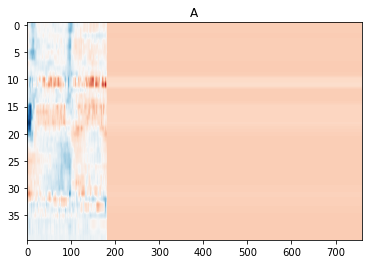

In [83]:
sample_ix = 23

plt.imshow(batch.features[sample_ix].T.squeeze().flipud(),cmap=cm.RdBu_r, aspect='auto')
plt.title(tokenizer.decode(batch.targets[sample_ix]))

Text(0.5, 1.0, '<unk>')

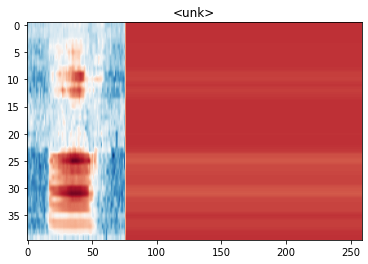

In [44]:
sample_ix = 0

plt.imshow(batch.features[sample_ix].T.squeeze().flipud(),cmap=cm.RdBu_r, aspect='auto')
plt.title(tokenizer.decode(batch.targets[sample_ix]))

In [204]:
import numpy as np 
x = np.random.rand(100,40)

In [207]:
 x.mean(0).shape

(40,)

In [157]:
x

array([[0.56635002, 0.04836337, 0.21508222, 0.00824944],
       [0.81506585, 0.93699676, 0.7327555 , 0.87915983]])